بسم الله

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from tabulate import tabulate
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/kaggle/input/ai-powered-resume-screening-dataset-2025/AI_Resume_Screening.csv")


# Display the first few rows to get an idea of our data
df.head()

,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
0,1,Ashley Ali,"TensorFlow, NLP, Pytorch",10,B.Sc,NaN,AI Researcher,Hire,104895,8,100
1,2,Wesley Roman,"Deep Learning, Machine Learning, Python, SQL",10,MBA,Google ML,Data Scientist,Hire,113002,1,100
2,3,Corey Sanchez,"Ethical Hacking, Cybersecurity, Linux",1,MBA,Deep Learning Specialization,Cybersecurity Analyst,Hire,71766,7,70
3,4,Elizabeth Carney,"Python, Pytorch, TensorFlow",7,B.Tech,AWS Certified,AI Researcher,Hire,46848,0,95
4,5,Julie Hill,"SQL, React, Java",4,PhD,NaN,Software Engineer,Hire,87441,9,100


In [3]:
df.dtypes


Resume_ID                  int64
Name                      object
Skills                    object
Experience (Years)         int64
Education                 object
Certifications            object
Job Role                  object
Recruiter Decision        object
Salary Expectation ($)     int64
Projects Count             int64
AI Score (0-100)           int64
dtype: object

In [4]:
df.shape


(1000, 11)

In [5]:
df.duplicated().sum()


0

In [6]:
df.isna().sum()


Resume_ID                   0
Name                        0
Skills                      0
Experience (Years)          0
Education                   0
Certifications            274
Job Role                    0
Recruiter Decision          0
Salary Expectation ($)      0
Projects Count              0
AI Score (0-100)            0
dtype: int64

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Resume_ID               1000 non-null   int64 
 1   Name                    1000 non-null   object
 2   Skills                  1000 non-null   object
 3   Experience (Years)      1000 non-null   int64 
 4   Education               1000 non-null   object
 5   Certifications          726 non-null    object
 6   Job Role                1000 non-null   object
 7   Recruiter Decision      1000 non-null   object
 8   Salary Expectation ($)  1000 non-null   int64 
 9   Projects Count          1000 non-null   int64 
 10  AI Score (0-100)        1000 non-null   int64 
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [8]:
df.describe(include="all")


,Resume_ID,Name,Skills,Experience (Years),Education,Certifications,Job Role,Recruiter Decision,Salary Expectation ($),Projects Count,AI Score (0-100)
count,1000.000000,1000,1000,1000.000000,1000,726,1000,1000,1000.000000,1000.00000,1000.000000
unique,NaN,989,238,NaN,5,3,4,2,NaN,NaN,NaN
top,NaN,Sarah Jones,"Ethical Hacking, Networking",NaN,B.Sc,Deep Learning Specialization,AI Researcher,Hire,NaN,NaN,NaN
freq,NaN,3,11,NaN,205,255,257,812,NaN,NaN,NaN
mean,500.500000,NaN,NaN,4.896000,NaN,NaN,NaN,NaN,79994.486000,5.13300,83.950000
std,288.819436,NaN,NaN,3.112695,NaN,NaN,NaN,NaN,23048.472549,3.23137,20.983036
min,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,40085.000000,0.00000,15.000000
25%,250.750000,NaN,NaN,2.000000,NaN,NaN,NaN,NaN,60415.750000,2.00000,70.000000
50%,500.500000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,79834.500000,5.00000,100.000000
75%,750.250000,NaN,NaN,8.000000,NaN,NaN,NaN,NaN,99583.250000,8.00000,100.000000


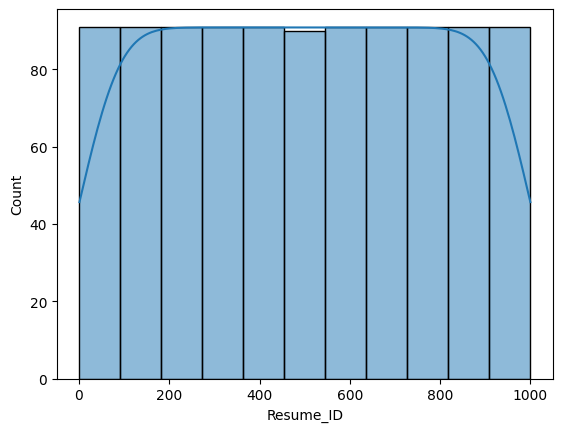

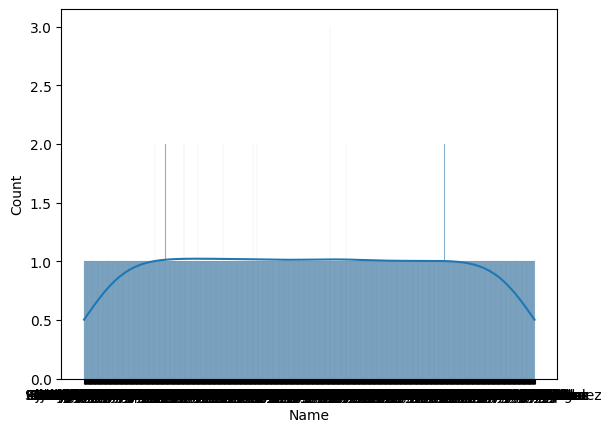

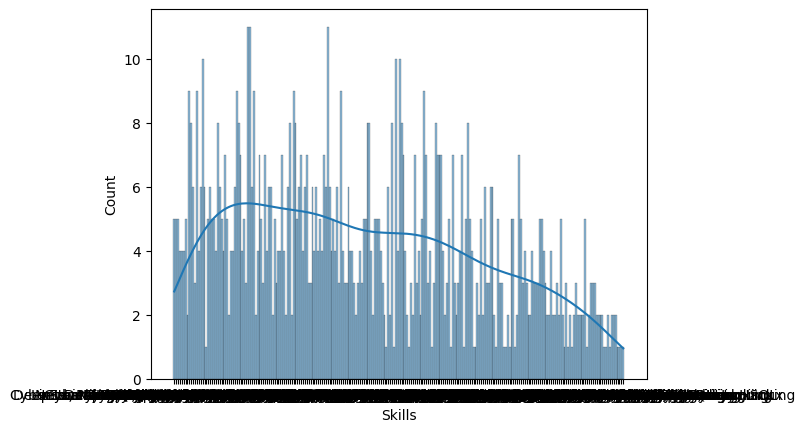

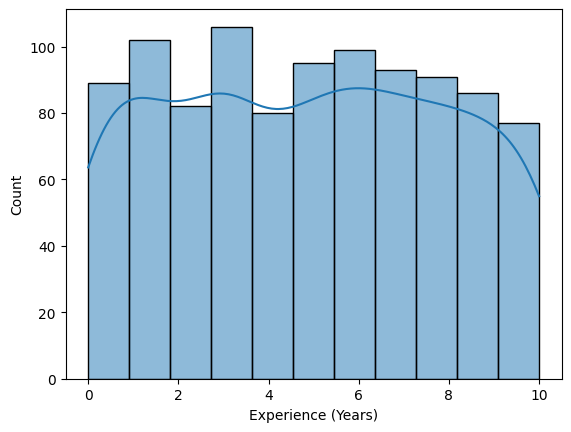

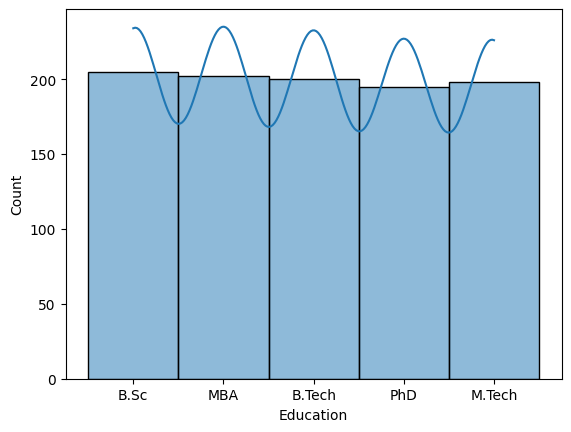

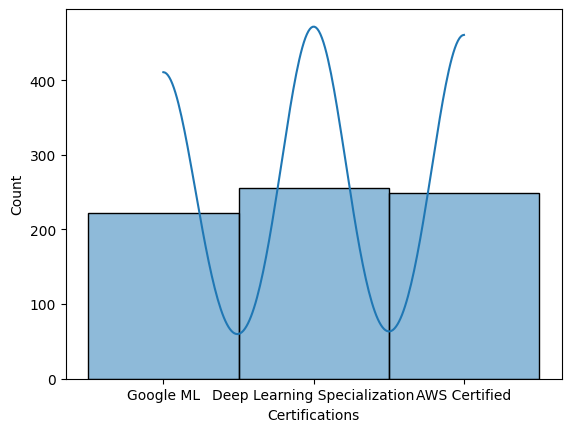

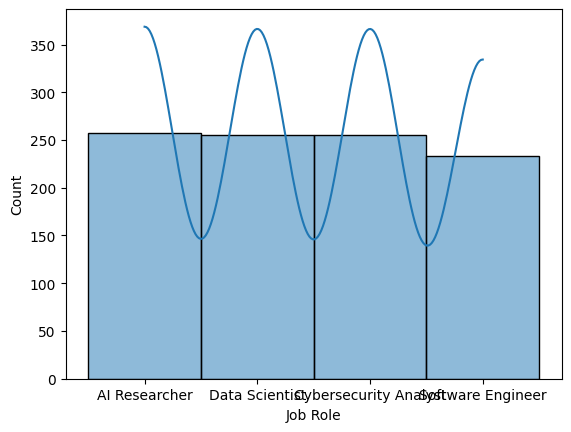

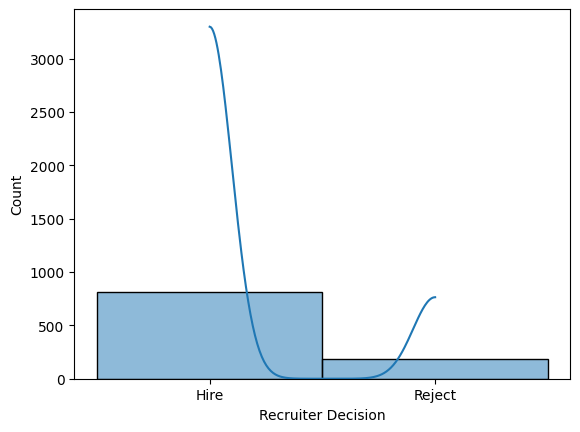

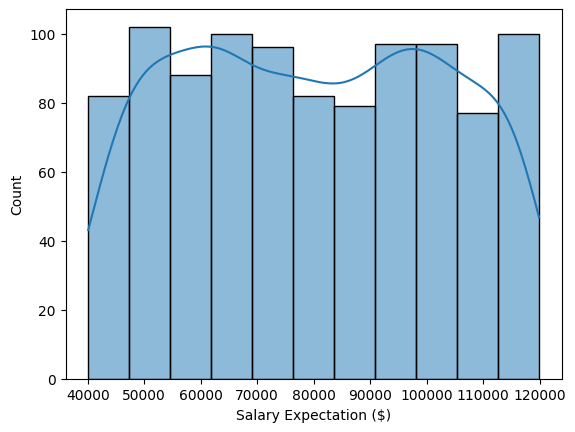

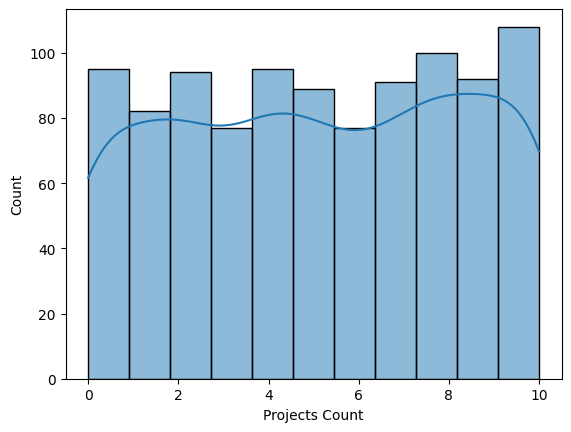

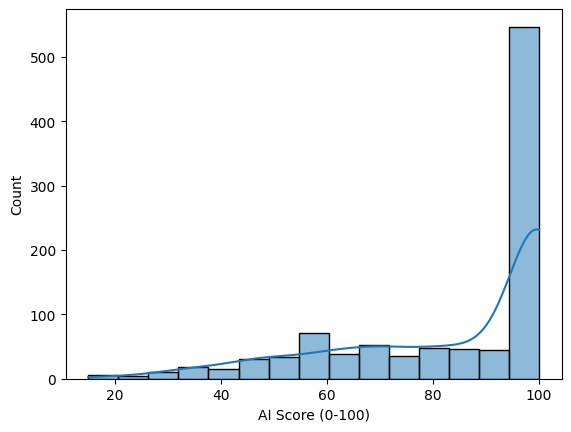

In [9]:
for col in df:
    sns.histplot(x=col,data=df,kde=True)
    plt.show()

In [10]:
df.drop_duplicates(inplace=True)

# Trim whitespace in string columns which can be a common source of errors
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

# For this dataset, there's no explicit date column. If there were dates, we might use pd.to_datetime() to convert them.

print('Data cleaning completed. Frame shape:', df.shape)

Data cleaning completed. Frame shape: (1000, 11)
